# **IPL DATA ANALYTICS PROJECT**

### **OBJECTIVE**
To analyze IPL match and player performance data and uncover
insights related to:
- Toss impact
- Match phases
- Batting performance
- Bowling performance
- Hidden winning patterns

### **TOOLS USED**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

### **AUTHOR**
Rashi Singh

**LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

**LOADING DATASET**

In [ ]:
df = pd.read_csv('/content/att_0_1778303821_c3a907.csv')

/tmp/ipykernel_2217/2912296416.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/att_0_1778303821_c3a907.csv')


**DATASET UNDERSTANDING**

In [ ]:
df.head()


,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,non_striker,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out
0,1082591,05-04-2017,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
1,1082591,05-04-2017,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
2,1082591,05-04-2017,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,4,0,4,0,0,0,0,NaN,NaN
3,1082591,05-04-2017,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
4,1082591,05-04-2017,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,2,2,2,0,0,0,NaN,NaN


In [ ]:
df.shape

(289673, 30)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289673 entries, 0 to 289672
Data columns (total 30 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   match_id           289673 non-null  int64  
 1   date               289673 non-null  object 
 2   season             289673 non-null  object 
 3   event              289673 non-null  object 
 4   venue              289673 non-null  object 
 5   city               277276 non-null  object 
 6   team1              289673 non-null  object 
 7   team2              289673 non-null  object 
 8   toss_winner        289673 non-null  object 
 9   toss_decision      289673 non-null  object 
 10  winner             289673 non-null  object 
 11  win_by_runs        133547 non-null  float64
 12  win_by_wickets     151146 non-null  float64
 13  player_of_match    288845 non-null  object 
 14  innings            289673 non-null  int64  
 15  batting_team       289673 non-null  object 
 16  ov

In [ ]:
df.describe()

,match_id,win_by_runs,win_by_wickets,innings,over,ball,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes
count,2.896730e+05,133547.000000,151146.000000,289673.000000,289673.000000,289673.000000,289673.000000,289673.000000,289673.000000,289673.000000,289673.000000,289673.000000,289673.000000
mean,9.654832e+05,30.217766,6.115266,1.482793,9.190563,3.628167,1.285477,0.068184,1.353661,0.039565,0.004277,0.004705,0.019601
std,3.911715e+05,26.530801,1.823510,0.502495,5.680221,1.818353,1.659483,0.342671,1.645469,0.255822,0.068964,0.114363,0.190069
min,3.359820e+05,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.483650e+05,11.000000,5.000000,1.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.082626e+06,22.000000,6.000000,1.000000,9.000000,4.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.304085e+06,41.000000,7.000000,2.000000,14.000000,5.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.529292e+06,146.000000,10.000000,6.000000,19.000000,11.000000,6.000000,7.000000,7.000000,5.000000,5.000000,4.000000,5.000000


**DATA CLEANING**

In [ ]:
df.isnull().sum()

,0
match_id,0
date,0
season,0
event,0
venue,0
city,12397
team1,0
team2,0
toss_winner,0
toss_decision,0


In [ ]:
columns = ['winner', 'team1', 'team2', 'toss_winner', 'batting_team']
for col in columns:
    df[col] = df[col].str.strip()      # remove spaces
    df[col] = df[col].str.title()

    df[col] = df[col].replace({
        'Delhi Daredevils': 'Delhi Capitals',
        'Kings XI Punjab': 'Punjab Kings',
        'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
        'Deccan Chargers': 'Sunrisers Hyderabad',
        'Gujarat Lions': 'Gujarat Lions',
        'Rising Pune Supergiant': 'Rising Pune Supergiants',
        'Rising Pune Supergiants': 'Rising Pune Supergiants',
        'Pune Warriors': 'Rising Pune Supergiants',
        'Sunrisers Hyderabad': 'Sunrisers Hyderabad',
        'Kolkata Knight Riders': 'Kolkata Knight Riders',
        'Mumbai Indians': 'Mumbai Indians',
        'Chennai Super Kings': 'Chennai Super Kings',
        'Rajasthan Royals': 'Rajasthan Royals',
        'Kochi Tuskers Kerala': 'Kochi Tuskers Kerala',
        'Kings XI Punjab': 'Punjab Kings',
        'Delhi Daredevils': 'Delhi Capitals'
    })

In [ ]:
print(df['season'].unique())

[2017 2018 2019 2020 2021 2022 2023 2024 2025 '2025' '2007/08' '2009'
 '2009/10' '2011' 2011 2012 2013 2014 2015 2016 2026]


**Ques 1 : Do teams winning toss win more matches?**

In [ ]:
df['toss_match_win'] = np.where(
    df['toss_winner'] == df['winner'],
    'Yes',
    'No'
)

df['toss_match_win'].value_counts(normalize=True) * 100

,proportion
toss_match_win,
Yes,50.19522
No,49.80478


/tmp/ipykernel_2217/2879027357.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


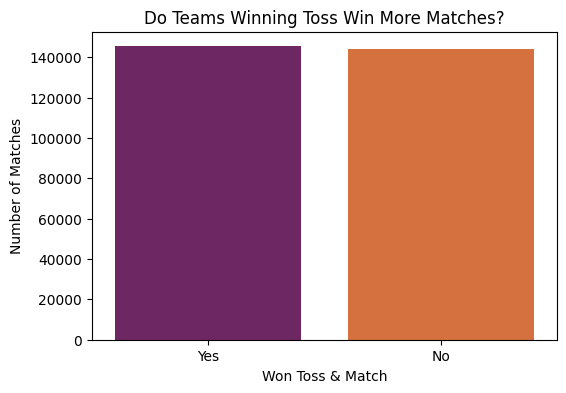

In [ ]:
toss_result = df['toss_match_win'].value_counts()

plt.figure(figsize=(6,4))

sns.barplot(
    x=toss_result.index,
    y=toss_result.values,
    palette = 'inferno'
)

plt.title("Do Teams Winning Toss Win More Matches?")
plt.xlabel("Won Toss & Match")
plt.ylabel("Number of Matches")

plt.show()

Insight : Teams winning the toss have a slight advantage, but toss alone doesnt guarantee victory.

**Ques 2 : Which match phase impacts victory most?**

In [ ]:
def phase(over):
    if over <= 6:
        return 'Powerplay'
    elif over <= 15:
        return 'Middle'
    else:
        return 'Death'

df['phase'] = df['over'].apply(phase)

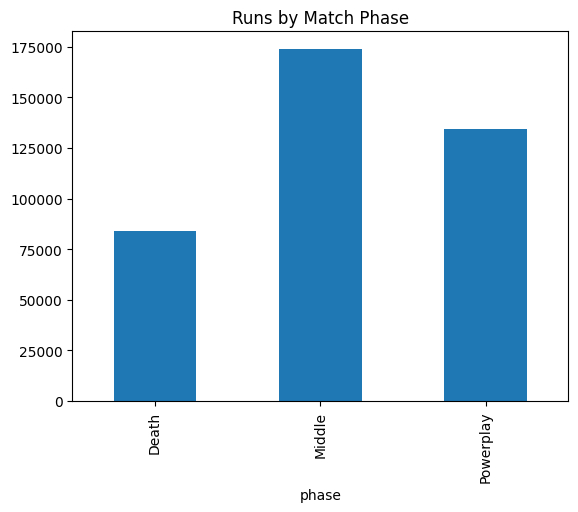

In [ ]:
phase_runs = df.groupby('phase')['runs_total'].sum()

phase_runs.plot(kind='bar')
plt.title("Runs by Match Phase")
plt.show()

In [ ]:
phase_sr = df.groupby('phase')['runs_batter'].mean() * 100
print(phase_sr)

phase
Death        153.914850
Middle       125.869424
Powerplay    119.557338
Name: runs_batter, dtype: float64


/tmp/ipykernel_2217/4243327072.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


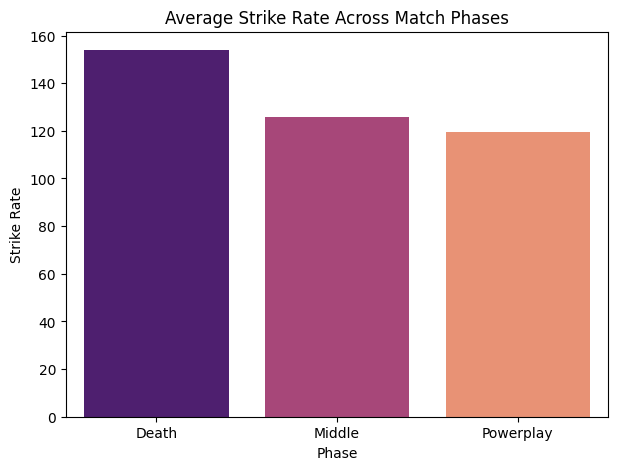

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=phase_sr.index,
    y=phase_sr.values,
    palette='magma'
)

plt.title("Average Strike Rate Across Match Phases")
plt.xlabel("Phase")
plt.ylabel("Strike Rate")

plt.show()

Insight : Death overs show the highest strike rate due to aggressive batting, while middle overs contribute the highest total runs.

**Ques 3 : Tops Batters and Bowlers across seasons**

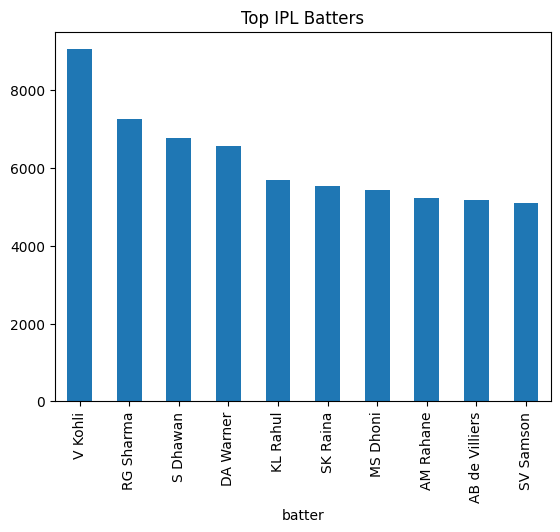

In [ ]:
top_batters = df.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(10)

top_batters.plot(kind='bar')
plt.title("Top IPL Batters")
plt.show()

In [ ]:
season_batter_runs = df.groupby(['season', 'batter'])['runs_batter'].sum().reset_index()
top_season = season_batter_runs.sort_values(
    ['season','runs_batter'],
    ascending=[True,False]
).groupby('season').head(1)
print(top_season)

       season         batter  runs_batter
93       2011   SR Tendulkar          182
146      2012       CH Gayle          733
372      2013     MEK Hussey          733
550      2014     RV Uthappa          660
610      2015      DA Warner          562
845      2016        V Kohli          973
884      2017      DA Warner          641
1056     2018  KS Williamson          735
1156     2019      DA Warner          692
1328     2020       KL Rahul          676
1513     2021     RD Gaikwad          635
1606     2022     JC Buttler          863
1885     2023   Shubman Gill          890
2068     2024        V Kohli          741
2137     2025       N Pooran          349
2242     2026      H Klaasen          494
2469  2007/08       SE Marsh          616
2583     2009      ML Hayden          572
2800  2009/10   SR Tendulkar          618
2852     2011       CH Gayle          436
3108     2025       SA Yadav          506


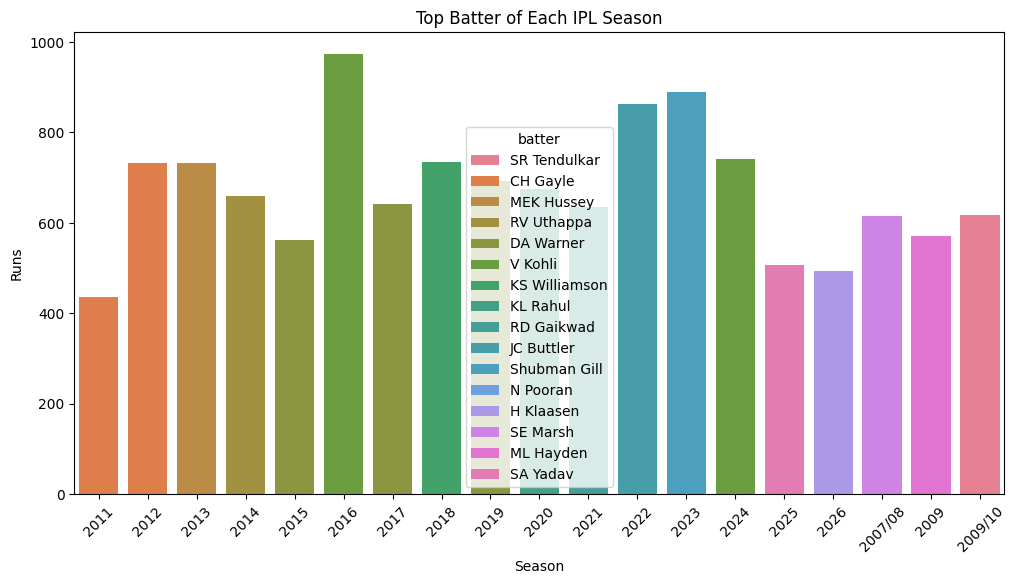

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_season,
    x='season',
    y='runs_batter',
    hue='batter'
)

plt.title("Top Batter of Each IPL Season")
plt.xlabel("Season")
plt.ylabel("Runs")

plt.xticks(rotation=45)

plt.show()

*Insight* : The 5 top IPL Batsman are
1. Virat Kohli
2. R G Sharma
3. S Dhawan
4. DA Warner
5. K L Rahul
 and Orange Cap of each season is visually displayed through charts

In [ ]:
wickets = df[df['wicket_kind'].notnull()]

top_bowlers = wickets.groupby('bowler')['wicket_player_out'].count().sort_values(ascending=False).head(10)
print(top_bowlers)

bowler
YS Chahal     238
B Kumar       231
SP Narine     223
JJ Bumrah     207
DJ Bravo      207
R Ashwin      205
PP Chawla     201
SL Malinga    188
RA Jadeja     186
A Mishra      183
Name: wicket_player_out, dtype: int64


In [ ]:
economy = df.groupby('bowler')['runs_total'].sum() / (
    df.groupby('bowler').size()/6
)
print(economy)

bowler
A Ashish Reddy     8.888889
A Badoni           9.365854
A Chandila         6.282051
A Choudhary        8.000000
A Dananjaya       11.280000
                    ...    
Yash Thakur        9.877895
Yudhvir Singh     10.634483
Yuvraj Singh       7.421769
Z Khan             7.539543
Zeeshan Ansari     9.588517
Length: 571, dtype: float64


/tmp/ipykernel_2217/729972247.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


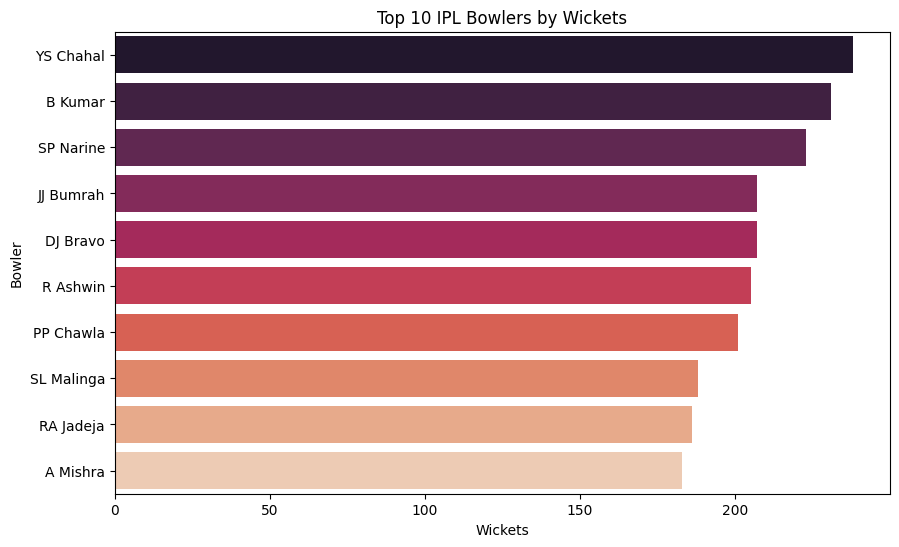

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_bowlers.values,
    y=top_bowlers.index,
    palette='rocket'
)

plt.title("Top 10 IPL Bowlers by Wickets")
plt.xlabel("Wickets")
plt.ylabel("Bowler")

plt.show()

*Insight* : Top 5 bowlers are
1. Y S Chahal
2. B Kumar
3. S P Narine
4. JJ Bumrah
5. DJ Bravo

**EXTRA KEY FINDINGS**

**Best Chasing Teams**

In [ ]:
chasing = df[df['win_by_wickets'].notnull()]

best_chasing = chasing['winner'].value_counts().head(10)
print(best_chasing)

winner
Kolkata Knight Riders          18499
Mumbai Indians                 18035
Delhi Capitals                 17398
Chennai Super Kings            17276
Rajasthan Royals               17037
Royal Challengers Bengaluru    16815
Sunrisers Hyderabad            13731
Kings Xi Punjab                10563
Gujarat Titans                  6477
Punjab Kings                    5470
Name: count, dtype: int64


Insight : The best chasing team is Kolkata Knight Riders

**Best Defending Teams**

In [ ]:
defending = df[df['win_by_runs'].notnull()]
best_defending = defending['winner'].value_counts().head(10)
print(best_defending)

winner
Mumbai Indians                 18867
Chennai Super Kings            18313
Sunrisers Hyderabad            17206
Royal Challengers Bengaluru    15561
Kolkata Knight Riders          13721
Rajasthan Royals               11737
Delhi Capitals                 11573
Kings Xi Punjab                 9599
Lucknow Super Giants            4990
Punjab Kings                    4178
Name: count, dtype: int64


Insight : The best defending team is Mumbai Indians

**Venues vs Wins Analysis**

In [ ]:
venue_wins = df.groupby(['venue', 'winner']).size().reset_index(name='wins')

print(venue_wins.head())


                  venue                       winner  wins
0  Arun Jaitley Stadium          Chennai Super Kings   246
1  Arun Jaitley Stadium               Delhi Capitals  1637
2  Arun Jaitley Stadium              Kings Xi Punjab   251
3  Arun Jaitley Stadium               Mumbai Indians   247
4  Arun Jaitley Stadium  Royal Challengers Bengaluru   245


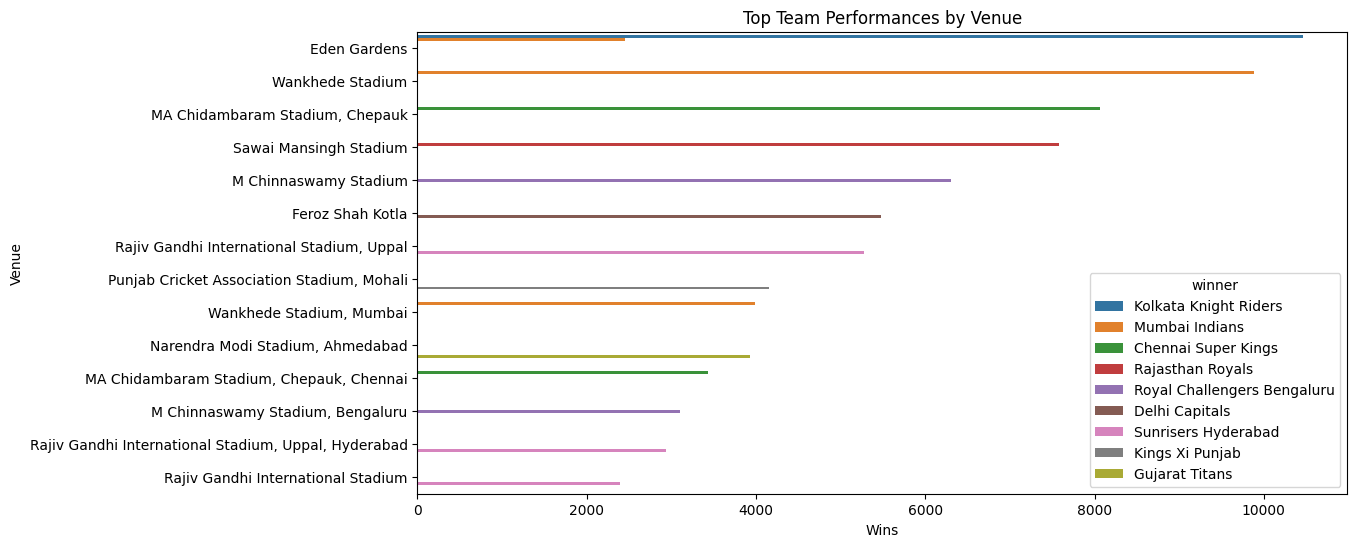

In [ ]:
top_venues = venue_wins.sort_values(
    by='wins',
    ascending=False
).head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_venues,
    x='wins',
    y='venue',
    hue='winner'
)

plt.title("Top Team Performances by Venue")
plt.xlabel("Wins")
plt.ylabel("Venue")

plt.show()

Insight : Venues can also influence the chance of winning of a certain team

**Toss Decision Impact**

In [ ]:
df.groupby('toss_decision')['winner'].count()

Insight : After winning the toss the team choosing the field is on a slight advantage

**Team Performance by Stadium**

In [ ]:
team_stadium = df.groupby(
    ['winner', 'venue']
).size().reset_index(name='wins')

print(team_stadium.head())

**Most Dangerous Death Overs Batters**

Filtering Death Overs

In [ ]:
death_overs = df[df['over'] > 15]
print(death_overs.head())

**Strike Rate in Death Overs**

Strike Rate = Runs/Balls * 100

In [ ]:
death_sr = df.groupby('batter').agg({
    'runs_batter':'sum',
    'ball':'count'
})

death_sr['strike_rate'] = (
    death_sr['runs_batter'] /
    death_sr['ball']
) * 100

death_sr = death_sr.sort_values(
    by='strike_rate',
    ascending=False
).head(10)

print(death_sr)

**Boundary Percentage** = Boundary Balls/ Total Balls  * 100

In [ ]:
boundaries = df[
    df['runs_batter'].isin([4,6])
]

boundary_percent = boundaries.groupby('batter').size() / \
                    df.groupby('batter').size() * 100

boundary_percent = boundary_percent.sort_values(
    ascending=False
).head(10)

print(boundary_percent)

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=death_sr['strike_rate'],
    y=death_sr.index,
    palette='magma'
)

plt.title("Most Dangerous Death Over Batters")
plt.xlabel("Strike Rate")
plt.ylabel("Batter")

plt.show()

*Insight* : Batters who performed best in death overs were not always the highest overall run scorers, but they had the greatest impact on match momentum due to rapid scoring in the final overs.

**Most Economical Death Bowlers**

Filter Death Overs

In [ ]:
death_bowling = df[df['over'] > 15]

**Econnomy Rate** = Runs covered / Overs Bowled

In [ ]:
economy = df.groupby('bowler').agg({
    'runs_total':'sum',
    'ball':'count'
})

economy['overs'] = economy['ball'] / 6

economy['economy_rate'] = (
    economy['runs_total'] /
    economy['overs']
)

economy = economy.sort_values(
    by='economy_rate'
).head(10)

print(economy)

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=economy['economy_rate'],
    y=economy.index,
    palette='viridis'
)

plt.title("Most Economical Death Bowlers")
plt.xlabel("Economy Rate")
plt.ylabel("Bowler")

plt.show()

*Insight* : While death overs are generally the most expensive phase for bowlers, a few specialists maintained remarkably low economy rates, making them critical assets in defending totals.

**Top Clutch Batsman**

In [ ]:
clutch_batters = df.groupby('batter')[
    'runs_batter'
].sum().sort_values(
    ascending=False
).head(10)

print(clutch_batters)

**CONSISTENCY ANALYSIS**
Lower standard deviation = more consistent

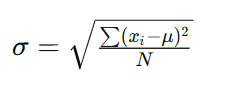

**Batter Consistency**

In [ ]:
player_scores = df.groupby(
    ['match_id', 'batter']
)['runs_batter'].sum().reset_index()

consistency = player_scores.groupby(
    'batter'
)['runs_batter'].std().sort_values()

print(consistency.head(10))

**Most Consistent High Scorers**

In [ ]:
avg_runs = player_scores.groupby(
    'batter'
)['runs_batter'].mean()

consistent_players = pd.concat(
    [avg_runs, consistency],
    axis=1
)

consistent_players.columns = [
    'average_runs',
    'std_dev'
]

consistent_players = consistent_players[
    consistent_players['average_runs'] > 25
]

consistent_players = consistent_players.sort_values(
    by='std_dev'
)

print(consistent_players.head(10))

In [ ]:
top_consistent = consistent_players.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_consistent['std_dev'],
    y=top_consistent.index,
    palette='coolwarm'
)

plt.title("Most Consistent IPL Batters")
plt.xlabel("Standard Deviation")
plt.ylabel("Player")

plt.show()

*Insight* : Players with lower standard deviation in match scores demonstrated greater consistency, indicating their ability to contribute stable performances across different match situations.

# Final Conclusions

1. Toss provides only a slight advantage.
2. Death overs are the most aggressive phase.
3. Certain teams dominate while chasing.
4. Top bowlers consistently influence outcomes.
5. Middle overs play a stabilizing role in innings construction.

# Future Improvements

- Match winner prediction using Machine Learning
- Live win probability analysis
- Fantasy team optimization
- Interactive dashboards

In [ ]:
import pandas as pd
from google.colab import files

# Save cleaned dataframe
df.to_csv("IPL_Cleaned.csv", index=False)

# Download file
files.download("IPL_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>